# `GEA` demo: disease-associated protein-protein interaction networks

This notebook is used as a demo of GEA's framework on building explainability out of a GNN model trained on disease-associated protein-protein interaction networks.

-----

**Main objectives:**

- Fetch disease-associated gene sets from the [DISEASES](https://diseases.jensenlab.org/) database, and extract their corresponding protein-protein interaction networks for protein-coding genes from the [STRING](https://string-db.org/) database.
- Build the graph dataset doing post-processing of the resulting networks and adding ESM-2 embeddings to each node as feature (this gives each node an unique identity).
- Train a Graph Neural Network (GNN) model on (1) reconstructing the node identity, (2) predicting the interaction score between two nodes, and (3) a semi-supervised contrastive learning objective to group together graphs from the same disease category.
- Building explainability using GEA at the node-, edge- and graph-level embeddings (i.e. training 3 Sparse Autoencoders (SAEs) and attributing features to a known ontology for the genes).

## Fetching data from databases

### Exploring the DISEASES database

#### Setup

In [ ]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
DATA_DIR.mkdir(parents=True, exist_ok=True)

#### The DISEASES data

DISEASES publishes one flat file per evidence channel — no API key needed. We use `integrated`, which combines curated knowledge, GWAS and text mining and gives the best gene coverage per disease.

Each row is one (protein, disease) association with a confidence score from 0 (low) to 5 (high) stars.

In [ ]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest


DISEASES_URL = "https://download.jensenlab.org/human_disease_integrated_full.tsv"
DISEASES_FILE = download_file(DISEASES_URL, DATA_DIR / "human_disease_integrated_full.tsv")

print(f"{DISEASES_FILE.name}: {DISEASES_FILE.stat().st_size / 1e6:.0f} MB")

The `integrated` channel has five columns and no header row: a STRING protein id, the gene symbol, a Disease Ontology id (DOID), the disease name, and the confidence score.

The `doid` column also carries a few non-DOID entries (ICD10 chapter codes, one OMIM id) that the Disease Ontology can't place — we keep DOID-prefixed rows only.

In [ ]:
COLUMNS = ["gene_id", "gene_symbol", "doid", "doid_name", "conf"]

diseases = pd.read_csv(DISEASES_FILE, sep="\t", header=None, names=COLUMNS)
diseases = diseases[diseases["doid"].str.startswith("DOID:")].reset_index(drop=True)
diseases.head()

We could also check the amount of entries and each type of variable inside the `diseases` dataframe.

In [ ]:
print(f"{len(diseases):,} rows")
print(diseases.dtypes)

### Filtering diseases

#### Confidence of genes being associated to a disease

The `conf` column is a 0–5 star scale: higher means more confident the gene is really associated with the disease.

In [ ]:
import matplotlib.pyplot as plt

print(diseases["conf"].describe())

diseases["conf"].hist(bins=20)
plt.xlabel("confidence"); plt.ylabel("n associations"); plt.title("DISEASES confidence scores")
plt.show()

Most of the mass sits below 2 stars (thin text-mining evidence). DISEASES' own documentation treats confidence ≥ 2 as the floor for a believable association, so we apply it before looking further.

In [ ]:
MIN_CONF = 2.0

n_before = len(diseases)
diseases_conf = diseases[diseases["conf"] >= MIN_CONF].reset_index(drop=True)
print(f"{n_before:,} → {len(diseases_conf):,} rows with confidence >= {MIN_CONF}")

We can now evaluate how many distinct diseases we have after the filtering of low confident genes and distinct genes associated to any disease.

In [ ]:
print(f"{diseases_conf['doid'].nunique():,} distinct diseases")
print(f"{diseases_conf['gene_symbol'].nunique():,} distinct genes")

#### Redundant diseases by gene size

Some entries are specific diseases with a handful of genes; others are broad umbrella terms from the Disease Ontology (e.g. "disease", "cancer") that list thousands. Worth seeing both ends.

In [ ]:
genes_per_disease = (
    diseases_conf.groupby(["doid", "doid_name"])["gene_symbol"]
    .nunique()
    .sort_values(ascending=False)
)

genes_per_disease.describe()

In [ ]:
print("Largest gene sets:")
print(genes_per_disease.head(10))

print("\nSmallest gene sets:")
print(genes_per_disease.tail(10))

Diseases with very few genes carry too little signal, and diseases with thousands are Disease Ontology groupings (`Disease`, `Cancer`, `Genetic disease`, …) rather than specific diseases. We keep gene-set sizes in a reasonable range in between.

In [ ]:
MIN_GENES_PER_DISEASE = 50
MAX_GENES_PER_DISEASE = 2000

too_small = genes_per_disease[genes_per_disease < MIN_GENES_PER_DISEASE]
too_large = genes_per_disease[genes_per_disease > MAX_GENES_PER_DISEASE]
keep_dois = genes_per_disease[
    (genes_per_disease >= MIN_GENES_PER_DISEASE) & (genes_per_disease <= MAX_GENES_PER_DISEASE)
].index.get_level_values("doid")

n_before = diseases_conf["doid"].nunique()
diseases_range = diseases_conf[diseases_conf["doid"].isin(keep_dois)].reset_index(drop=True)

print(f"dropped {len(too_small):,} diseases with < {MIN_GENES_PER_DISEASE} genes")
print(f"dropped {len(too_large):,} diseases with > {MAX_GENES_PER_DISEASE} genes, e.g. "
      + ", ".join(name for _, name in too_large.index[:5]))
print(f"\n{n_before:,} → {diseases_range['doid'].nunique():,} diseases kept")

#### Removing diseases with identical gene sets

Some DOIDs are near-synonyms that DISEASES' text mining cannot tell apart (e.g. "Leiomyosarcoma" and "Smooth muscle cancer") and end up with the exact same gene set under two different labels. We keep one representative per group of diseases sharing an identical gene set.

In [ ]:
gene_sets = (
    diseases_range.groupby(["doid", "doid_name"])["gene_symbol"]
    .apply(frozenset)
    .reset_index()
)

dup_mask = gene_sets["gene_symbol"].duplicated(keep=False)
twin_groups = gene_sets[dup_mask].groupby("gene_symbol")["doid"].apply(list)

print(f"{dup_mask.sum():,} diseases in {len(twin_groups):,} groups share an identical gene set, e.g.:")
names_by_doid = gene_sets.set_index("doid")["doid_name"]
for dois in twin_groups.head(5):
    print("   " + " = ".join(names_by_doid.loc[dois]))

# one representative per group (the alphabetically first doid), the rest are dropped as duplicates
drop_dois = {doid for dois in twin_groups for doid in sorted(dois)[1:]}

n_before = diseases_range["doid"].nunique()
diseases_unique = diseases_range[~diseases_range["doid"].isin(drop_dois)].reset_index(drop=True)
print(f"\n{n_before:,} → {diseases_unique['doid'].nunique():,} diseases after dropping {len(drop_dois):,} twins")

We can also look into one specific disease. As an example, type 2 diabetes mellitus (`DOID:9352`) and its associated genes, ranked by confidence, are showcased.

In [ ]:
doid = "DOID:9352"
example = diseases_unique[diseases_unique["doid"] == doid].sort_values("conf", ascending=False)

print(f"{example['doid_name'].iloc[0]}: {len(example)} associations, "
      f"{example['gene_symbol'].nunique()} distinct genes")
example.head(15)

Let's save the filtered dataset with all disease-associated gene sets into our data folder.

In [ ]:
diseases_unique.to_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t", index=False)

### Fetching protein-protein interaction networks from STRING

#### Setup

In [ ]:
from pathlib import Path

import pandas as pd
import requests

DATA_DIR = Path("data/diseases")
STRING_DIR = DATA_DIR / "string"
STRING_DIR.mkdir(parents=True, exist_ok=True)

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
print(f"{len(diseases):,} associations | {diseases['doid'].nunique():,} diseases | "
      f"{diseases['gene_id'].nunique():,} proteins")

#### The STRING data

[STRING](https://string-db.org/) publishes one flat file of all pairwise interaction scores per species, so no API key needed either for this case. Each row is one (protein, protein) pair with a combined confidence score from 0 to 1000, aggregating evidence from experiments, curated databases, co-expression, text mining and more.

In [ ]:
def download_file(url, dest):
    if dest.exists():
        return dest
    print(f"downloading {url}")
    with requests.get(url, stream=True, timeout=180, headers={"User-Agent": "gea-diseases-demo/1.0"}) as resp:
        resp.raise_for_status()
        with open(dest, "wb") as fh:
            for chunk in resp.iter_content(1 << 20):
                fh.write(chunk)
    return dest

STRING_URL = "https://stringdb-downloads.org/download/protein.links.v12.0/9606.protein.links.v12.0.txt.gz"
STRING_FILE = download_file(STRING_URL, STRING_DIR / "9606.protein.links.v12.0.txt.gz")

print(f"{STRING_FILE.name}: {STRING_FILE.stat().st_size / 1e6:.0f} MB")

The dataframe has one row per interacting protein pair. STRING ids carry a species prefix (`9606.` for human), which we drop so they match the protein ids already in our disease table.

In [ ]:
string_links = pd.read_csv(STRING_FILE, sep=" ", compression="gzip")
string_links["protein1"] = string_links["protein1"].str.removeprefix("9606.")
string_links["protein2"] = string_links["protein2"].str.removeprefix("9606.")
string_links.head()

As the DISEASES dataframe, we can also look into the amount of rows (protein interactions) and the columns type the dataframe has.

In [ ]:
print(f"{len(string_links):,} rows")
print(string_links.dtypes)

### Filtering interactions based on confidence score

#### High confidence interaction filter

The overall confidence score that is made aggregating every evidence channel of a protein-protein interaction in STRING is given by `combined_score` (its range is 0–1000). STRING's own "high confidence" cutoff is 700.

In [ ]:
from matplotlib import pyplot as plt

print(string_links["combined_score"].describe())

string_links["combined_score"].hist(bins=20)
plt.axvline(700, color="k", ls="--", lw=1, label="STRING high confidence = 700")
plt.xlabel("combined_score"); plt.ylabel("n interactions"); plt.title("STRING confidence scores")
plt.legend(); plt.show()

We keep only high-confidence interactions (`combined_score >= 700`, STRING's own "high confidence" band). Medium confidence (`>= 400`) would keep far more edges, but pulls in a lot of weaker, text-mining-only evidence — and we're already leaning on DISEASES' text-mined associations for the disease genes, so keeping the network side clean avoids compounding two noisy sources.

In [ ]:
STRING_MIN_SCORE = 700

n_before = len(string_links)
string_links = string_links[string_links["combined_score"] >= STRING_MIN_SCORE].reset_index(drop=True)
print(f"{n_before:,} → {len(string_links):,} interactions with combined_score >= {STRING_MIN_SCORE}")

We can evaluate how many unique proteins and interactions we end up on the final set.

In [ ]:
n_proteins = pd.concat([string_links["protein1"], string_links["protein2"]]).nunique()
print(f"{n_proteins:,} distinct proteins")
print(f"{len(string_links):,} interactions")

#### Interactions per protein

Like the disease gene sets, this is heavy-tailed: most proteins have a handful of high-confidence partners, while a few hub proteins have thousands.

In [ ]:
interactions_per_protein = (
    pd.concat([string_links["protein1"], string_links["protein2"]])
    .value_counts()
)

print(interactions_per_protein.describe())
print("\nMost connected proteins:")
print(interactions_per_protein.head(10))

As an example, `INS` (insulin, `ENSP00000380432`) — one of the type 2 diabetes genes from before — and its highest-confidence interaction partners.

In [ ]:
protein = "ENSP00000380432"
example = string_links[(string_links["protein1"] == protein) | (string_links["protein2"] == protein)]
example = example.sort_values("combined_score", ascending=False)

print(f"{protein}: {len(example)} interactions")
example.head(15)

We can save these protein-protein interactions on our data folder.

In [ ]:
string_links.to_csv(DATA_DIR / "string_filtered.tsv", sep="\t", index=False)

## Disease-associated protein-protein interaction networks

### Building the networks

#### Setup

In [ ]:
import pandas as pd
from pathlib import Path

DATA_DIR = Path("data/diseases")
STRING_DIR = DATA_DIR / "string"

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")

print(f"{diseases['doid'].nunique():,} diseases | {diseases['gene_id'].nunique():,} disease genes")
print(f"{len(string_links):,} interactions | "
      f"{pd.concat([string_links['protein1'], string_links['protein2']]).nunique():,} proteins")

#### Disease graphs construction

For each disease, the network is the **induced subgraph** of STRING restricted to that disease's associated genes: nodes are the disease genes, edges are the high-confidence STRING interactions between them. No 1-hop expansion — only interactions where both proteins are already disease genes.

We build the full STRING graph once, then take one induced subgraph per disease out of it.

In [ ]:
import networkx as nx

G_string = nx.from_pandas_edgelist(string_links, "protein1", "protein2", edge_attr="combined_score")
print(f"{G_string.number_of_nodes():,} nodes | {G_string.number_of_edges():,} edges")

gene_sets = diseases.groupby(["doid", "doid_name"])["gene_id"].apply(set)

disease_graphs = {}
rows = []
for (doid, doid_name), genes in gene_sets.items():
    G = G_string.subgraph(genes)
    disease_graphs[doid] = G
    rows.append({"doid": doid, "doid_name": doid_name,
                 "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges()})

graph_sizes = pd.DataFrame(rows).sort_values("n_nodes", ascending=False)
print(f"\n{len(disease_graphs):,} disease networks built")

#### Network sizes

Genes with no high-confidence partner among the *other* disease genes end up isolated in a disease's
own network, so node and edge counts shrink further from the raw gene-set sizes.

In [ ]:
print(graph_sizes[["n_nodes", "n_edges"]].describe())

print("\nLargest networks:")
print(graph_sizes.head(10).to_string(index=False))

print("\nSmallest networks:")
print(graph_sizes.tail(10).to_string(index=False))

Back to type 2 diabetes mellitus (`DOID:9352`) we have been using as an example, its network alongside its raw gene set is showcased.

In [ ]:
doid = "DOID:9352"
G = disease_graphs[doid]
n_genes = diseases.loc[diseases["doid"] == doid, "gene_id"].nunique()

print(f"Type 2 diabetes mellitus: {n_genes} disease genes → "
      f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges in the network")

### ESM-2 embeddings as a node flag

There is a huge problem on network analysis, and if the plan is to use graph to train graph neural networks then the model has no way to know the node identity. Therefore, we can flag each protein in every graph by concatenating a representative vector to its feature. In this case, we opt to use ESM-2 embeddings as a way to flag every protein.

#### Writing the protein list

Our graph nodes are already Ensembl/STRING protein ids (`ENSP...`), and `get_esm_protein_embeddings.py`
looks sequences up by protein id directly — no gene mapping needed, and no isoforms to aggregate,
since a protein id already names one specific sequence.

In [ ]:
proteins = sorted(diseases["gene_id"].unique())

PROTEIN_LIST_FILE = DATA_DIR / "ensembl_protein_ids.txt"
PROTEIN_LIST_FILE.write_text("\n".join(proteins))
print(f"{len(proteins):,} disease proteins written to {PROTEIN_LIST_FILE}")

#### Computing the embeddings

Run this from the repo root, in the `gea` conda environment. It downloads the human Ensembl proteome
FASTA on first use and needs a GPU to be practical for ~9,850 proteins:

```bash
python3 docs/scripts/get_esm_protein_embeddings.py \
    --protein-list docs/tutorial/data/diseases/ensembl_protein_ids.txt \
    --out          docs/tutorial/data/diseases/esm_protein_embeddings.pt \
    --species      human \
    --model        facebook/esm2_t33_650M_UR50D \
    --batch-size 8
```

This writes `{protein_id: tensor([1280])}` to `esm_protein_embeddings.pt` — one embedding per protein,
directly loadable by `gea.utils.load_esm_protein_embeddings`. Come back here once it's finished.

#### Loading the embeddings

`load_esm_protein_embeddings` is a direct per-protein lookup (no isoform aggregation needed), and
still L2-normalises each embedding and fills a random Gaussian vector for any protein missing from
the file — so it never blocks on a handful of misses.

In [ ]:
from gea.utils import load_esm_protein_embeddings

ESM_FILE = DATA_DIR / "esm_protein_embeddings.pt"

all_proteins = sorted(set(protein for G in disease_graphs.values() for protein in G.nodes))
esm_embeddings = load_esm_protein_embeddings(str(ESM_FILE), all_proteins)
protein_to_esm = dict(zip(all_proteins, esm_embeddings))

print(f"{esm_embeddings.shape[0]:,} proteins | {esm_embeddings.shape[1]}-dim ESM-2 embeddings")

#### Node features: `[conf, esm_embedding]`

The association confidence is disease-specific (the same protein carries a different score in each
disease it belongs to); the ESM-2 embedding is protein identity and stays the same across diseases.
Each node's feature is the two concatenated.

In [ ]:
import torch

for doid, G in disease_graphs.items():
    disease_conf = (
        diseases.loc[diseases["doid"] == doid]
        .drop_duplicates("gene_id")
        .set_index("gene_id")["conf"]
    )
    node_features = {
        protein: torch.cat([torch.tensor([disease_conf.get(protein, 0.0)]), protein_to_esm[protein]])
        for protein in G.nodes
    }
    nx.set_node_attributes(G, node_features, "x")

print(f"node feature dim: {1 + esm_embeddings.shape[1]} (1 confidence score + {esm_embeddings.shape[1]} ESM-2 dims)")

As before, `INS` (insulin, `ENSP00000380432`) in the type 2 diabetes mellitus network (`DOID:9352`).

In [ ]:
G = disease_graphs["DOID:9352"]
x = G.nodes["ENSP00000380432"]["x"]

print(f"feature shape: {tuple(x.shape)}")
print(f"conf={x[0]:.3f} | esm[:5]={x[1:6]}")

#### Saving the networks

We pickle `disease_graphs` as-is (one `networkx.Graph` per disease, each node already carrying its
`x` feature tensor) so later notebooks can reload it directly for EDA and training, without rebuilding
the networks or recomputing ESM-2 embeddings.

In [ ]:
import pickle

GRAPHS_FILE = DATA_DIR / "disease_graphs.pkl"
with open(GRAPHS_FILE, "wb") as f:
    pickle.dump(disease_graphs, f)

print(f"{len(disease_graphs):,} disease networks saved to {GRAPHS_FILE}")

### Graph Exploratory Data Analysis

#### Setup

Disease categories (cancer, infectious, immune, …) aren't in `diseases_filtered.tsv` — they're read
off the Disease Ontology's own `is_a` hierarchy by `docs/scripts/build_disease_categories.py`, which
walks each DOID up to whichever of 18 broad category roots it descends from (first match wins, so a
lung carcinoma is filed under "cancer" rather than "respiratory"). Run once:

```bash
python3 docs/scripts/build_disease_categories.py \
    --diseases docs/tutorial/data/diseases/diseases_filtered.tsv \
    --out      docs/tutorial/data/diseases/disease_categories.tsv
```

That produced `disease_categories.tsv` (`doid`, `doid_name`, `category`), loaded below as `categories`.

In [ ]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx

DATA_DIR = Path("data/diseases")

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
string_links = pd.read_csv(DATA_DIR / "string_filtered.tsv", sep="\t")
categories = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t")

with open(DATA_DIR / "disease_graphs.pkl", "rb") as f:
    disease_graphs = pickle.load(f)

G_string = nx.from_pandas_edgelist(string_links, "protein1", "protein2", edge_attr="combined_score")

print(f"{len(disease_graphs):,} disease networks | {diseases['doid'].nunique():,} diseases")
print(f"{categories['category'].nunique():,} categories: "
      + ", ".join(categories["category"].value_counts().index))
print(f"STRING background: {G_string.number_of_nodes():,} proteins, {G_string.number_of_edges():,} edges")

#### Diseases per category

`categories` gives us, for the first time, a way to group diseases into something biologically
meaningful beyond raw gene-set size.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

order = categories["category"].value_counts().index

fig, ax = plt.subplots(figsize=(7, 6))
sns.countplot(data=categories, y="category", order=order, color="#4C72B0", ax=ax)
ax.set(xlabel="n diseases", ylabel="", title="Diseases per category")
plt.tight_layout(); plt.show()

print(categories["category"].value_counts().to_string())

#### Network size by category

Does disease category track with network size?

In [ ]:
graph_sizes = pd.DataFrame([
    {"doid": doid, "n_nodes": G.number_of_nodes(), "n_edges": G.number_of_edges()}
    for doid, G in disease_graphs.items()
]).merge(categories, on="doid")

order = graph_sizes.groupby("category")["n_nodes"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=graph_sizes, y="category", x="n_nodes", order=order, color="#4C72B0", ax=ax)
ax.set(xscale="log", xlabel="n nodes (log scale)", ylabel="", title="Network size by disease category")
plt.tight_layout(); plt.show()

print(graph_sizes.groupby("category")["n_nodes"].median().sort_values(ascending=False).to_string())

Mental and genetic diseases have the largest median node counts, syndromes and "other" the smallest —
but every box spans well over an order of magnitude, so category alone is a weak predictor of size.
Consistent with what we already saw in the DISEASES section: size is driven mostly by how much has
been published about a disease, not by which organ system or disease class it belongs to.

#### Association confidence by category

Do some categories carry stronger evidence than others?

In [ ]:
conf_by_cat = diseases[["doid", "conf"]].merge(categories[["doid", "category"]], on="doid")

order = conf_by_cat.groupby("category")["conf"].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=conf_by_cat, y="category", x="conf", order=order, color="#4C72B0", ax=ax)
ax.set(xlabel="DISEASES confidence score", ylabel="", title="Association confidence by category")
plt.tight_layout(); plt.show()

print(conf_by_cat.groupby("category")["conf"].median().sort_values(ascending=False).to_string())

Median confidence barely moves across categories (roughly 2.2-2.4 out of the 0-5 scale) — evidence
quality is fairly uniform once the 2.0 floor has already been applied, so unlike network size,
confidence is not a useful category signal on its own.

#### The largest network in each category

A concrete anchor for what "large" means per category — the single biggest disease graph in each of
the 19.

In [ ]:
biggest_per_category = graph_sizes.loc[graph_sizes.groupby("category")["n_nodes"].idxmax()]
biggest_per_category = biggest_per_category.sort_values("n_nodes", ascending=False)
print(biggest_per_category[["category", "doid_name", "n_nodes", "n_edges"]].to_string(index=False))

## Graph Neural Network for disease-associated graphs

### Training

No contrastive objective here, deliberately. Training the encoder to also pull graphs of the same
disease category together would hand it the one label we actually care about predicting later — any
apparent "the network helps" result could just be an artifact of that supervision leaking in. Without
it, the encoder only has two things to prove itself on: can it rebuild a protein's identity from its
neighbours, and can it tell which pairs of proteins actually interact. Disease categories are still
loaded below, but only to build a train/val split — never as a training signal.

#### Setup

In [ ]:
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import networkx as nx
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
import torch_geometric.transforms as T
from torch_geometric.nn import GCNConv

from gea.gea import set_seed

DATA_DIR = Path("data/diseases")
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

with open(DATA_DIR / "disease_graphs.pkl", "rb") as f:
    disease_graphs = pickle.load(f)
categories = pd.read_csv(DATA_DIR / "disease_categories.tsv", sep="\t")
category_by_doid = categories.set_index("doid")["category"]

print(f"device: {device}")
print(f"{len(disease_graphs):,} disease networks loaded")

### From networkx to PyTorch Geometric

Each graph's node feature stays `[conf, esm_embedding]`, with one change: the raw ESM-2 embeddings are
**whitened** first. Real ESM-2 vectors for this protein set are extremely anisotropic — almost every
pair has cosine similarity ≈ 0.98 — so training against them directly barely constrains the encoder
(predicting the *average* embedding already scores ≈0.99 cosine, with nothing protein-specific learned
at all). `compress_embeddings_pca` rescales the space so directions that actually differ between
proteins count as much as the ones that don't, down to the specify dimensions.

Edges become bidirectional (`GCNConv` expects a directed edge list, so an undirected interaction needs
both directions) with `edge_attr = combined_score / 1000`, matching the 0-1 confidence convention used
throughout.

In [ ]:
from gea.utils import compress_embeddings_pca

esm_reduced_dim = 512

protein_to_esm_raw = {}
for G in disease_graphs.values():
    for p in G.nodes:
        if p not in protein_to_esm_raw:
            protein_to_esm_raw[p] = G.nodes[p]["x"][1:]

proteins_ordered = list(protein_to_esm_raw.keys())
esm_raw = torch.stack([protein_to_esm_raw[p] for p in proteins_ordered]).float()
esm_whitened = compress_embeddings_pca(esm_raw, n_components=esm_reduced_dim, whiten=True)
protein_to_esm_white = dict(zip(proteins_ordered, esm_whitened))


def to_pyg(doid, G):
    nodes = sorted(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    conf = torch.stack([G.nodes[n]["x"][:1] for n in nodes]).float()
    esm = torch.stack([protein_to_esm_white[n] for n in nodes]).float()
    x = torch.cat([conf, esm], dim=1)

    edges = list(G.edges(data="combined_score"))
    src = [idx[u] for u, v, _ in edges] + [idx[v] for u, v, _ in edges]
    dst = [idx[v] for u, v, _ in edges] + [idx[u] for u, v, _ in edges]
    weight = [s / 1000.0 for _, _, s in edges] * 2

    edge_index = torch.tensor([src, dst], dtype=torch.long)
    edge_attr = torch.tensor(weight, dtype=torch.float).view(-1, 1)
    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, doid=doid)


pyg_graphs = {doid: to_pyg(doid, G) for doid, G in disease_graphs.items()}
example = next(iter(pyg_graphs.values()))
print(f"{len(pyg_graphs):,} PyG graphs built | node feature dim {example.x.shape[1]} (1 conf + {esm_reduced_dim} whitened ESM)")

#### Held-out diseases, not just held-out edges

We split at the disease level first (90/10, stratified by category so both splits look similar) so
validation measures generalisation to diseases the encoder has never seen at all — a much harder and
more honest test than only hiding a few edges inside diseases it already trained on.

In [ ]:
all_doids = list(pyg_graphs.keys())
train_doids, val_doids = train_test_split(
    all_doids, test_size=0.2, random_state=SEED,
    stratify=[category_by_doid[d] for d in all_doids],
)
print(f"{len(train_doids):,} train diseases | {len(val_doids):,} val diseases")

#### Held-out edges within each graph

Within every graph, `RandomLinkSplit` hides 15% of its edges from message passing and pairs them with
an equal number of sampled non-edges. The encoder only ever sees the remaining 85% (`edge_index`);
the held-out set (`edge_label_index` / `edge_label`) is what actually tests whether it recovers
structure it wasn't shown, rather than memorising the edges it was trained on.

In [ ]:
MIN_EDGES = 20  # RandomLinkSplit needs enough edges left to make a sensible held-out set

link_splitter = T.RandomLinkSplit(
    num_val=0.0, num_test=0.15, is_undirected=True,
    add_negative_train_samples=True, neg_sampling_ratio=1.0,
)


def split_edges(doids):
    message, held_out, dropped = [], [], 0
    for doid in doids:
        data = pyg_graphs[doid]
        if data.num_edges < MIN_EDGES:
            dropped += 1
            continue
        train_data, _, test_data = link_splitter(data)
        message.append(train_data)
        held_out.append(test_data)
    return message, held_out, dropped


train_msg, train_eval, n_dropped_train = split_edges(train_doids)
val_msg, val_eval, n_dropped_val = split_edges(val_doids)

print(f"train: {len(train_msg):,} graphs ({n_dropped_train} dropped, < {MIN_EDGES} edges)")
print(f"val:   {len(val_msg):,} graphs ({n_dropped_val} dropped, < {MIN_EDGES} edges)")

### The model

Encoder: a 3-layer GCN with residual connections — a few rounds of neighbourhood averaging erode a
node's own identity, so each layer adds its update on top of the previous representation instead of
replacing it. Two decoders, no contrastive head:

- **node decoder** — a linear layer maps the embedding back to the whitened ESM-2 space, trained with
  a cosine loss against the real (whitened) embedding
- **edge decoder** — a plain dot product between two node embeddings, trained with binary
  cross-entropy against the held-out edges/non-edges from the previous step

In [ ]:
h_dim = esm_reduced_dim  # hidden dim for GCN layers
z_dim = 128

class ResidualGCN(nn.Module):
    def __init__(self, in_dim, hidden_dim=h_dim, out_dim=z_dim, n_layers=3, dropout=0.2):
        super().__init__()
        self.proj = nn.Linear(in_dim, hidden_dim)
        self.convs = nn.ModuleList([GCNConv(hidden_dim, hidden_dim) for _ in range(n_layers)])
        self.out_proj = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, edge_weight):
        h = self.proj(x)
        for conv in self.convs:
            h = h + F.relu(conv(h, edge_index, edge_weight))
            h = F.dropout(h, p=self.dropout, training=self.training)
        return self.out_proj(h)


class DiseaseGraphModel(nn.Module):
    def __init__(self, in_dim, esm_dim, hidden_dim=h_dim, out_dim=z_dim):
        super().__init__()
        self.encoder = ResidualGCN(in_dim, hidden_dim, out_dim)
        self.node_decoder = nn.Linear(out_dim, esm_dim)

    def encode(self, x, edge_index, edge_weight):
        return self.encoder(x, edge_index, edge_weight)

    def decode_edges(self, z, edge_label_index):
        src, dst = edge_label_index
        return (z[src] * z[dst]).sum(dim=-1)


in_dim = example.x.shape[1]
esm_dim = in_dim - 1  # x = [conf, esm_embedding]
model = DiseaseGraphModel(in_dim, esm_dim).to(device)
print(model)

#### Training

Total loss adds two extra terms to the node and edge objectives, still with no category anywhere in
sight. Neither of the two main objectives actually requires the encoder to spread information across
all 128 dimensions on its own — a **variance** term penalises any output dimension whose spread across
the batch collapses towards zero, and a **covariance** term penalises dimensions that duplicate each
other. Together they make using only a couple of dimensions actively penalised, rather than relying on
the node/edge objectives to rule it out by themselves.

In [ ]:
def variance_covariance_loss(z, eps=1e-4):
    """Penalise collapsed (near-zero variance) or duplicated (correlated) output dimensions."""
    z = z - z.mean(dim=0, keepdim=True)
    std = torch.sqrt(z.var(dim=0, unbiased=False) + eps)
    var_loss = torch.relu(1.0 - std).mean()

    n, d = z.shape
    cov = (z.T @ z) / (n - 1)
    off_diag = cov.flatten()[1:].view(d - 1, d + 1)[:, :-1].flatten()
    cov_loss = off_diag.pow(2).sum() / d
    return var_loss, cov_loss


def evaluate(model, msg_list, eval_list, batch_size=32):
    model.eval()
    cosines, aucs = [], []
    with torch.no_grad():
        for msg_batch, eval_batch in zip(
            DataLoader(msg_list, batch_size=batch_size, shuffle=False),
            DataLoader(eval_list, batch_size=batch_size, shuffle=False),
        ):
            msg_batch, eval_batch = msg_batch.to(device), eval_batch.to(device)
            z = model.encode(msg_batch.x, msg_batch.edge_index, msg_batch.edge_attr.squeeze(-1))

            node_pred = model.node_decoder(z)
            cosines.append(F.cosine_similarity(node_pred, msg_batch.x[:, 1:]).mean().item())

            logits = model.decode_edges(z, eval_batch.edge_label_index)
            y = eval_batch.edge_label.cpu().numpy()
            if len(set(y)) > 1:
                aucs.append(roc_auc_score(y, logits.sigmoid().cpu().numpy()))
    return float(np.mean(cosines)), float(np.mean(aucs))


EPOCHS = 100
BATCH_SIZE = 16
VAR_WEIGHT = 1.0
COV_WEIGHT = 0.05

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
train_loader = DataLoader(train_msg, batch_size=BATCH_SIZE, shuffle=True)

history = []
for epoch in range(EPOCHS):
    model.train()
    total_loss = total_var = total_cov = 0.0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        z = model.encode(batch.x, batch.edge_index, batch.edge_attr.squeeze(-1))
        node_pred = model.node_decoder(z)
        node_loss = 1 - F.cosine_similarity(node_pred, batch.x[:, 1:]).mean()

        edge_logits = model.decode_edges(z, batch.edge_label_index)
        edge_loss = F.binary_cross_entropy_with_logits(edge_logits, batch.edge_label)

        var_loss, cov_loss = variance_covariance_loss(z)

        loss = node_loss + edge_loss + VAR_WEIGHT * var_loss + COV_WEIGHT * cov_loss
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        total_var += var_loss.item() * batch.num_graphs
        total_cov += cov_loss.item() * batch.num_graphs

    train_loss = total_loss / len(train_msg)
    if epoch % 10 == 0 or epoch == EPOCHS - 1:
        val_cosine, val_auc = evaluate(model, val_msg, val_eval, BATCH_SIZE)
        history.append({
            "epoch": epoch, "train_loss": train_loss,
            "var_loss": total_var / len(train_msg), "cov_loss": total_cov / len(train_msg),
            "val_cosine": val_cosine, "val_auc": val_auc,
        })
        print(f"epoch {epoch:3d} | train loss {train_loss:.4f} | "
              f"val node cosine {val_cosine:.4f} | val edge AUC {val_auc:.4f}")

#### Is the encoder learning anything beyond degree?

A high edge AUC on its own isn't proof the encoder learned something interesting — the earlier
permutation test already showed disease genes are unusually interconnected, and simple structural
heuristics can ride on that fact for free. The sharpest baseline is **node degree**: score a candidate
pair by the product of how many message-passing edges each endpoint has, with no learned embedding at
all. If the trained model can't beat that, the "network matters" story would rest on nothing more than
hub genes being more likely to interact with everything — not on anything specific this encoder found.

Node reconstruction needs the same scrutiny, but a *random* vector is too easy a baseline in high
dimensions (two random 256-dim vectors are already near-orthogonal by construction). The honest
baseline is predicting the **dataset mean** embedding for every protein — the shortcut an un-whitened
target would otherwise let the model take for free.

In [ ]:
final_cosine, final_auc = evaluate(model, val_msg, val_eval, BATCH_SIZE)

# mean-embedding baseline for node reconstruction — the honest "did nothing" baseline once the target
# is whitened: always predict the dataset's average protein, no learned embedding at all
train_targets = torch.cat([pyg_graphs[d].x[:, 1:] for d in train_doids])
mean_target = train_targets.mean(dim=0)

mean_cosines = []
for doid in val_doids:
    target = pyg_graphs[doid].x[:, 1:]
    mean_cosines.append(F.cosine_similarity(target, mean_target.unsqueeze(0).expand_as(target)).mean().item())
mean_cosine = float(np.mean(mean_cosines))

# degree-product baseline for edge prediction — no learned embedding, just message-passing degree
degree_aucs = []
for msg, held_out in zip(val_msg, val_eval):
    degree = np.bincount(msg.edge_index[0].numpy(), minlength=msg.num_nodes)
    src, dst = held_out.edge_label_index.numpy()
    scores = degree[src] * degree[dst]
    y = held_out.edge_label.numpy()
    if len(set(y)) > 1:
        degree_aucs.append(roc_auc_score(y, scores))
degree_auc = float(np.mean(degree_aucs))

print(f"{'':22s}{'node cosine':>14s}{'edge AUC':>12s}")
print(f"{'mean / degree only':22s}{mean_cosine:14.4f}{degree_auc:12.4f}")
print(f"{'trained model':22s}{final_cosine:14.4f}{final_auc:12.4f}")

With the ESM-2 target whitened, node reconstruction is no longer a free ride: the trained model has to
clear a mean-embedding baseline that is now genuinely hard to beat, instead of matching a baseline that
was already at ≈0.99 by construction. The edge objective is the more interesting result: the encoder
now beats the degree-only baseline by a real margin, wider than what the earlier, collapsed
representation managed — evidence that at least part of the previous "edges barely help" reading was
the representation collapsing onto ~2 dimensions, not the edges themselves being uninformative. The
sanity check in the Evaluation section below confirms the embedding space is actually being used before
trusting any picture drawn from it.

#### Saving trained model

In [ ]:
CHECKPOINT_FILE = DATA_DIR / "disease_gcn.pt"
torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "val_node_cosine": final_cosine,
    "val_edge_auc": final_auc,
    "val_degree_auc": degree_auc,
    "train_doids": train_doids,
    "val_doids": val_doids,
}, CHECKPOINT_FILE)

print(f"Saved checkpoint to {CHECKPOINT_FILE}")

### Evaluation

#### Training curves

In [ ]:
history_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 4, figsize=(19, 4))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", color="#4C72B0")
axes[0].set(xlabel="epoch", ylabel="train loss", title="Training loss")

axes[1].plot(history_df["epoch"], history_df["val_cosine"], marker="o", color="#55A868")
axes[1].axhline(mean_cosine, color="k", ls="--", lw=1, label="mean-embedding baseline")
axes[1].set(xlabel="epoch", ylabel="val node cosine", title="Node reconstruction")
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["val_auc"], marker="o", color="#C44E52")
axes[2].axhline(degree_auc, color="k", ls="--", lw=1, label="degree baseline")
axes[2].set(xlabel="epoch", ylabel="val edge AUC", title="Edge prediction")
axes[2].legend()

axes[3].plot(history_df["epoch"], history_df["var_loss"], marker="o", color="#8172B2", label="variance loss")
axes[3].plot(history_df["epoch"], history_df["cov_loss"], marker="o", color="#CCB974", label="covariance loss")
axes[3].set(xlabel="epoch", ylabel="loss", title="Anti-collapse regularisers")
axes[3].legend()

plt.tight_layout(); plt.show()

#### Held-out edge prediction: model vs. degree baseline

The AUC numbers reported earlier are averaged one-graph-at-a-time. Pooling every held-out edge and
non-edge across all 92 validation diseases into a single ROC curve shows the same comparison directly.

In [ ]:
from sklearn.metrics import roc_curve

model.eval()
all_y, all_model_scores, all_degree_scores = [], [], []
with torch.no_grad():
    for msg, held_out in zip(val_msg, val_eval):
        z = model.encode(msg.x.to(device), msg.edge_index.to(device), msg.edge_attr.squeeze(-1).to(device))
        logits = model.decode_edges(z, held_out.edge_label_index.to(device)).sigmoid().cpu().numpy()

        degree = np.bincount(msg.edge_index[0].numpy(), minlength=msg.num_nodes)
        src, dst = held_out.edge_label_index.numpy()

        all_y.append(held_out.edge_label.numpy())
        all_model_scores.append(logits)
        all_degree_scores.append(degree[src] * degree[dst])

y_all = np.concatenate(all_y)
model_scores = np.concatenate(all_model_scores)
degree_scores = np.concatenate(all_degree_scores)

pooled_model_auc = roc_auc_score(y_all, model_scores)
pooled_degree_auc = roc_auc_score(y_all, degree_scores)

fpr_m, tpr_m, _ = roc_curve(y_all, model_scores)
fpr_d, tpr_d, _ = roc_curve(y_all, degree_scores)

fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.plot(fpr_m, tpr_m, color="#4C72B0", label=f"trained model (AUC {pooled_model_auc:.3f})")
ax.plot(fpr_d, tpr_d, color="#C44E52", ls="--", label=f"degree only (AUC {pooled_degree_auc:.3f})")
ax.plot([0, 1], [0, 1], color="grey", lw=1, ls=":")
ax.set(xlabel="false positive rate", ylabel="true positive rate",
       title="Held-out edges, pooled over 92 val diseases")
ax.legend()
plt.tight_layout(); plt.show()

#### Does performance vary by disease size?

A single mean AUC can hide a lot: maybe the model is great on large, well-connected diseases and
close to chance on small ones. Breaking it down per validation disease, and against network size,
checks that directly.

In [ ]:
per_disease = []
model.eval()
with torch.no_grad():
    for msg, held_out in zip(val_msg, val_eval):
        z = model.encode(msg.x.to(device), msg.edge_index.to(device), msg.edge_attr.squeeze(-1).to(device))
        logits = model.decode_edges(z, held_out.edge_label_index.to(device)).sigmoid().cpu().numpy()
        y = held_out.edge_label.numpy()
        if len(set(y)) > 1:
            per_disease.append({"doid": msg.doid, "n_nodes": msg.num_nodes, "auc": roc_auc_score(y, logits)})

per_disease = pd.DataFrame(per_disease)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].hist(per_disease["auc"], bins=20, color="#4C72B0")
axes[0].axvline(pooled_degree_auc, color="k", ls="--", lw=1, label="degree baseline (pooled)")
axes[0].set(xlabel="edge AUC", ylabel="n diseases", title="Per-disease edge AUC (held-out)")
axes[0].legend()

axes[1].scatter(per_disease["n_nodes"], per_disease["auc"], alpha=0.6, color="#4C72B0")
axes[1].set(xscale="log", xlabel="n nodes (log scale)", ylabel="edge AUC", title="Edge AUC vs. disease size")

plt.tight_layout(); plt.show()

print(f"corr(n_nodes, edge AUC) = {per_disease['n_nodes'].corr(per_disease['auc']):.3f}")
print(per_disease["auc"].describe())

#### Extracting node, edge and graph embeddings

For everything below we re-encode every disease using its **full** network (all edges, not the 85%
message-passing subset used for validation) — these embeddings are meant for downstream analysis, not
for testing held-out generalisation. One forward pass per disease gives node embeddings `z`; a graph
embedding is `z` mean-pooled over nodes, an edge embedding is the mean of its two endpoints'
embeddings (keeping only one direction per pair, matching the convention `gea.gea.extract_embeddings`
already uses for LIONESS graphs).

In [ ]:
from gea.gea import ENTITY_SEP, GENE_PAIR_SEP, save_embeddings


def extract_all_levels():
    graph_emb, graph_entities, graph_doid, graph_category = [], [], [], []
    node_emb, node_entities, node_doid, node_category, node_protein = [], [], [], [], []
    edge_emb, edge_entities, edge_doid, edge_category, edge_a, edge_b = [], [], [], [], [], []

    model.eval()
    with torch.no_grad():
        for doid, data in pyg_graphs.items():
            z = model.encode(
                data.x.to(device), data.edge_index.to(device), data.edge_attr.squeeze(-1).to(device)
            ).cpu()
            nodes = sorted(disease_graphs[doid].nodes())  # same order used by to_pyg
            category = category_by_doid.get(doid, "other")

            graph_emb.append(z.mean(dim=0, keepdim=True).numpy())
            graph_entities.append(doid)
            graph_doid.append(doid)
            graph_category.append(category)

            node_emb.append(z.numpy())
            node_entities.extend(f"{doid}{ENTITY_SEP}{p}" for p in nodes)
            node_doid.extend([doid] * len(nodes))
            node_category.extend([category] * len(nodes))
            node_protein.extend(nodes)

            src, dst = data.edge_index[0].numpy(), data.edge_index[1].numpy()
            keep = src < dst  # both directions are stored; keep one copy per pair
            src, dst = src[keep], dst[keep]
            edge_emb.append(((z[src] + z[dst]) / 2.0).numpy())
            edge_entities.extend(f"{doid}{ENTITY_SEP}{nodes[s]}{GENE_PAIR_SEP}{nodes[d]}" for s, d in zip(src, dst))
            edge_doid.extend([doid] * len(src))
            edge_category.extend([category] * len(src))
            edge_a.extend(nodes[s] for s in src)
            edge_b.extend(nodes[d] for d in dst)

    graph_export = {
        "embeddings": np.concatenate(graph_emb, axis=0).astype(np.float32),
        "entities": np.array(graph_entities, dtype=object),
        "doid": np.array(graph_doid, dtype=object),
        "category": np.array(graph_category, dtype=object),
        "level": np.array("graph"),
    }
    node_export = {
        "embeddings": np.concatenate(node_emb, axis=0).astype(np.float32),
        "entities": np.array(node_entities, dtype=object),
        "doid": np.array(node_doid, dtype=object),
        "category": np.array(node_category, dtype=object),
        "protein": np.array(node_protein, dtype=object),
        "level": np.array("node"),
    }
    edge_export = {
        "embeddings": np.concatenate(edge_emb, axis=0).astype(np.float16),
        "entities": np.array(edge_entities, dtype=object),
        "doid": np.array(edge_doid, dtype=object),
        "category": np.array(edge_category, dtype=object),
        "protein_a": np.array(edge_a, dtype=object),
        "protein_b": np.array(edge_b, dtype=object),
        "level": np.array("edge"),
    }
    return graph_export, node_export, edge_export


graph_export, node_export, edge_export = extract_all_levels()
print(f"graph: {graph_export['embeddings'].shape}")
print(f"node:  {node_export['embeddings'].shape}")
print(f"edge:  {edge_export['embeddings'].shape}")

#### Graph-level embeddings, visualised by category

The encoder never saw disease category — it only ever optimised the node and edge objectives. Colouring
its graph embeddings by category here is a purely post-hoc diagnostic: any clustering by category
would be an emergent property of gene identity + topology, not something trained for directly.

In [ ]:
import umap

reducer = umap.UMAP(random_state=SEED)
graph_umap = reducer.fit_transform(graph_export["embeddings"])
graph_categories = graph_export["category"]

cats = sorted(set(graph_categories))
palette = dict(zip(cats, sns.color_palette("husl", len(cats))))

fig, ax = plt.subplots(figsize=(8, 7))
for cat in cats:
    mask = graph_categories == cat
    ax.scatter(graph_umap[mask, 0], graph_umap[mask, 1], s=16, alpha=0.75, color=palette[cat], label=cat)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2", title="Graph-level embeddings, coloured by category")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=1.5)
plt.tight_layout(); plt.show()

#### Graph-level embeddings, one panel per category

The single scatter above can only give a handful of categories a distinct colour before it turns into a legend soup. Splitting into one small panel per category — same UMAP layout underneath, just the categories with the most diseases shown first — makes it possible to see whether a Disease Ontology branch actually occupies its own region of the map, or is sprayed across all of it.

In [ ]:
panel_order = sorted(cats, key=lambda c: -(graph_categories == c).sum())
ncol = 5
nrow = int(np.ceil(len(panel_order) / ncol))

fig, axes = plt.subplots(nrow, ncol, figsize=(3.2 * ncol, 3.2 * nrow), sharex=True, sharey=True)
for ax, cat in zip(axes.ravel(), panel_order):
    mask = graph_categories == cat
    ax.scatter(graph_umap[~mask, 0], graph_umap[~mask, 1], s=4, color="#e8e8e8", linewidths=0, zorder=1)
    ax.scatter(graph_umap[mask, 0], graph_umap[mask, 1], s=11, color=palette[cat], alpha=0.9, linewidths=0, zorder=2)
    ax.set_title(f"{cat} ({int(mask.sum())})", fontsize=10)
    ax.set(xticks=[], yticks=[])
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_color("#dddddd")
for ax in axes.ravel()[len(panel_order):]:
    ax.axis("off")
fig.suptitle("Where each disease category sits on the same graph-embedding map "
             "(grey = every other disease)", fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

#### Node-level embeddings, visualised by category

There are far too many node instances (~250k, the same protein re-embedded differently in every
disease it belongs to) to plot directly, so we UMAP a random sample and colour each point by the
category of the disease graph it came from.

In [ ]:
N_NODE_SAMPLE = 8000

rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(node_export["embeddings"]), size=N_NODE_SAMPLE, replace=False)
node_sample_emb = node_export["embeddings"][sample_idx]
node_sample_cat = node_export["category"][sample_idx]

node_umap = umap.UMAP(random_state=SEED).fit_transform(node_sample_emb)

fig, ax = plt.subplots(figsize=(8, 7))
for cat in cats:
    mask = node_sample_cat == cat
    ax.scatter(node_umap[mask, 0], node_umap[mask, 1], s=6, alpha=0.5, color=palette[cat], label=cat)
ax.set(xlabel="UMAP 1", ylabel="UMAP 2",
       title=f"Node-level embeddings ({N_NODE_SAMPLE:,}-node sample), coloured by disease category")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8, markerscale=1.5)
plt.tight_layout(); plt.show()

#### Sanity check: is the embedding space actually being used?

A UMAP plot always finds *some* 2D layout, whether or not the underlying space has real structure — worth checking directly rather than trusting the picture. PCA on the graph- and node-level embeddings shows how much of the variance sits in just the first couple of components; if that number were close to 100%, the whole 128-dim space would have collapsed onto a line or a plane and the UMAP picture above would be showing noise, not structure.

In [ ]:
from sklearn.decomposition import PCA

for name, emb in [("graph", graph_export["embeddings"]), ("node", node_sample_emb)]:
    pca = PCA(n_components=5).fit(emb)
    cum = np.cumsum(pca.explained_variance_ratio_)
    print(f"{name:>5}-level: PC1 alone {pca.explained_variance_ratio_[0]:.1%} | "
          f"first 5 PCs {cum[-1]:.1%} of variance")

#### Saving the three levels

Node, edge and graph embeddings, saved separately so they can be used to train the three GEA SAEs
(node-, edge- and graph-level) afterwards. Entity ids follow `gea.gea`'s own naming convention
(`ENTITY_SEP`, `GENE_PAIR_SEP`) so they read the same way as the LIONESS exports do. Edge-level is
by far the largest (one row per gene pair per disease), so it's stored as `float16`.

In [ ]:
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
EMBEDDINGS_DIR.mkdir(parents=True, exist_ok=True)

paths = {
    "graph": save_embeddings(EMBEDDINGS_DIR / "disease_gcn_graph.npz", graph_export),
    "node": save_embeddings(EMBEDDINGS_DIR / "disease_gcn_node.npz", node_export),
    "edge": save_embeddings(EMBEDDINGS_DIR / "disease_gcn_edge.npz", edge_export),
}
for level, path in paths.items():
    size_mb = Path(path).stat().st_size / 1e6
    print(f"{level:>5}: {path}  ({size_mb:.0f} MB)")

## Sparse Autoencoders

### Setup

Each SAE trains directly on the embeddings already saved to disk — this section doesn't depend on anything from the GNN training kernel state, only the three `.npz` files.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

import gea.gea as gea_module
from gea.gea import ShallowSAE, train_sae, set_seed

DATA_DIR = Path("data/diseases")
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Same train/val disease split the GNN used, saved inside its own checkpoint — node- and edge-level
# training below restricts itself to train_doids so val_doids stays genuinely unseen by everything,
# including the concept-annotation test later in this notebook.
gnn_ckpt = torch.load(DATA_DIR / "disease_gcn.pt", map_location="cpu", weights_only=False)
train_doids, val_doids = gnn_ckpt["train_doids"], gnn_ckpt["val_doids"]

print(f"device: {device}")
print(f"{len(train_doids):,} GNN-train diseases | {len(val_doids):,} GNN-held-out diseases")

device: cuda
736 GNN-train diseases | 184 GNN-held-out diseases


### A minimal dataset for `train_sae`

`gea.gea.train_sae` only ever reads `batch['embedding']`, but `gea.dataloader.EmbeddingDataset` also requires `prediction`/`target` fields from the LIONESS/GNNModel pipeline that our unsupervised export never produced. A dataset that wraps just the embeddings is all that's actually needed here.

In [2]:
class EmbeddingOnlyDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = torch.tensor(np.asarray(embeddings).astype(np.float32))

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return {"embedding": self.embeddings[idx]}

### Training one SAE per level

`ShallowSAE` is a plain dictionary-learning autoencoder (linear encoder, ReLU, linear decoder, L1
sparsity penalty, decoder weights renormalised every step so features can't collapse to zero).
Graph-level trains on all 920 diseases — it's never used in the held-out concept-annotation test
below, so there is nothing to protect it from. Node- and edge-level train **only on `train_doids`**,
the same diseases the GNN itself trained on: that way `val_doids` stays genuinely unseen by the SAE
too, and the held-out test later in this notebook doesn't need a second, separately-trained SAE just
to get that guarantee — training the same dictionary twice would be pure waste. The progress bar is
muted (`train_sae`'s own `tqdm` swapped out during the call) so it doesn't flood the notebook with
thousands of progress lines.

In [3]:
class _NoOpProgressBar:
    """Drop-in tqdm replacement: same interface, does nothing — keeps train_sae's
    per-step progress bar out of the saved notebook (it would otherwise dump
    thousands of lines of text into the cell output)."""
    def __init__(self, iterable, **kwargs):
        self._iterable = iterable

    def __iter__(self):
        return iter(self._iterable)

    def set_postfix(self, **kwargs):
        pass

    def update(self, *args, **kwargs):
        pass

    def close(self):
        pass


def train_disease_sae(level, latent_dim, epochs, batch_size=256, val_frac=0.1, doid_subset=None):
    data = np.load(EMBEDDINGS_DIR / f"disease_gcn_{level}.npz", allow_pickle=True)
    embeddings = data["embeddings"]
    if doid_subset is not None:
        embeddings = embeddings[np.isin(data["doid"], doid_subset)]
    dataset = EmbeddingOnlyDataset(embeddings)

    n_val = max(1, int(val_frac * len(dataset)))
    train_ds, val_ds = random_split(
        dataset, [len(dataset) - n_val, n_val],
        generator=torch.Generator().manual_seed(SEED),
    )
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    sae = ShallowSAE(in_dim=dataset.embeddings.shape[1], latent_dim=latent_dim)
    model_path = EMBEDDINGS_DIR / f"sae_{level}.pt"
    loss_path = EMBEDDINGS_DIR / f"sae_{level}_loss.csv"

    scope = (f"{len(dataset):,} rows from {len(doid_subset):,} diseases" if doid_subset is not None
             else f"{len(dataset):,} rows")
    print(f"=== {level}-level SAE: {scope}, {dataset.embeddings.shape[1]} -> {latent_dim} dims ===")

    _tqdm, gea_module.tqdm = gea_module.tqdm, _NoOpProgressBar
    try:
        train_sae(sae, train_loader, val_loader, device, epochs=epochs,
                  model_path=str(model_path), loss_path=str(loss_path))
    finally:
        gea_module.tqdm = _tqdm

    sae.load_state_dict(torch.load(model_path))  # keep the best-val checkpoint, not the last epoch
    return sae

#### Graph-level SAE

In [4]:
graph_sae = train_disease_sae("graph", latent_dim=1024, epochs=200, batch_size=128)

=== graph-level SAE: 920 rows, 128 -> 1024 dims ===

Training losses saved to: data/diseases/embeddings/sae_graph_loss.csv
Best validation loss: 0.0030 at epoch 179


#### Node-level SAE

Trained only on `train_doids` rows (see above).

In [5]:
node_sae = train_disease_sae("node", latent_dim=1024, epochs=30, batch_size=256, doid_subset=train_doids)

=== node-level SAE: 196,902 rows from 736 diseases, 128 -> 1024 dims ===

Training losses saved to: data/diseases/embeddings/sae_node_loss.csv
Best validation loss: 0.0142 at epoch 28


#### Edge-level SAE

Trained only on `train_doids` rows (see above).

In [6]:
edge_sae = train_disease_sae("edge", latent_dim=1024, epochs=20, batch_size=1024, doid_subset=train_doids)

=== edge-level SAE: 2,757,214 rows from 736 diseases, 128 -> 1024 dims ===

Training losses saved to: data/diseases/embeddings/sae_edge_loss.csv
Best validation loss: 0.0073 at epoch 18


#### Training curves, all three levels

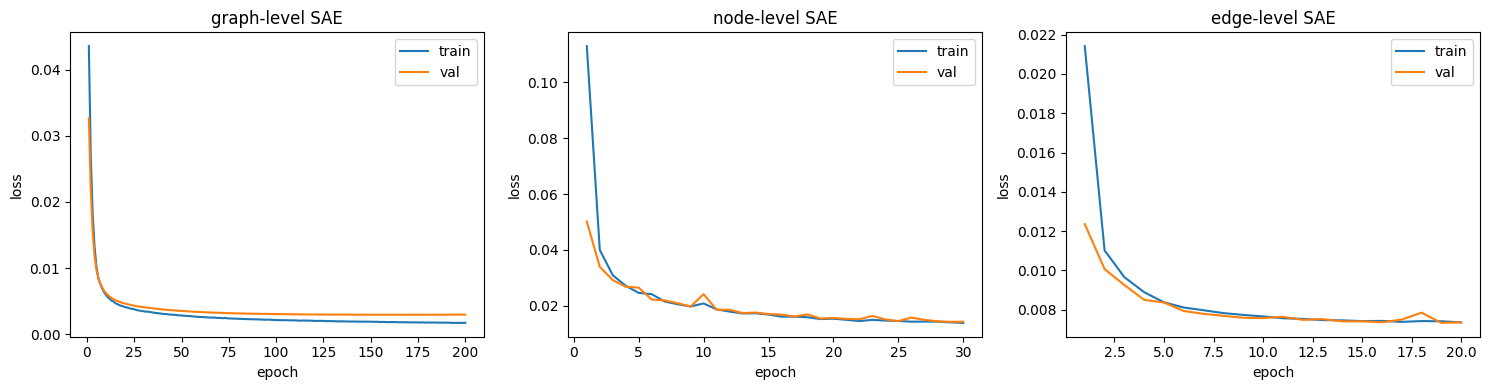

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, level in zip(axes, ["graph", "node", "edge"]):
    loss_df = pd.read_csv(EMBEDDINGS_DIR / f"sae_{level}_loss.csv")
    ax.plot(loss_df["epoch"], loss_df["train_loss"], label="train")
    ax.plot(loss_df["epoch"], loss_df["val_loss"], label="val")
    ax.set(xlabel="epoch", ylabel="loss", title=f"{level}-level SAE")
    ax.legend()
plt.tight_layout(); plt.show()

#### Saving the SAE weights

`train_sae` already checkpoints the best-validation state to disk during training (`sae_{level}.pt`, one per level) — this just confirms what's there.

In [8]:
sae_paths = {level: EMBEDDINGS_DIR / f"sae_{level}.pt" for level in ["graph", "node", "edge"]}
for level, path in sae_paths.items():
    size_kb = path.stat().st_size / 1e3
    print(f"{level:>5}: {path}  ({size_kb:.0f} KB)")

graph: data/diseases/embeddings/sae_graph.pt  (1056 KB)
 node: data/diseases/embeddings/sae_node.pt  (1056 KB)
 edge: data/diseases/embeddings/sae_edge.pt  (1056 KB)


### Assigning concepts to SAE features

A feature is only interesting once we know what it responds to. This reuses the trained node- and edge-level SAEs plus the GNN's own train/val disease split (saved inside `disease_gcn.pt`) — the diseases the GNN never trained on double as the diseases held out from concept selection here, so a feature's assigned concept has to survive on genuinely unseen diseases, not just the ones it was picked from.

#### Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from gea.gea import ShallowSAE, set_seed
from gea_gene_nets.annotation_funcs import fetch_gene_sets, geneSetAnnotation, gene_set_matrix, feature_maxima

DATA_DIR = Path("data/diseases")
EMBEDDINGS_DIR = DATA_DIR / "embeddings"
SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

diseases = pd.read_csv(DATA_DIR / "diseases_filtered.tsv", sep="\t")
node_export = np.load(EMBEDDINGS_DIR / "disease_gcn_node.npz", allow_pickle=True)
edge_export = np.load(EMBEDDINGS_DIR / "disease_gcn_edge.npz", allow_pickle=True)

gnn_ckpt = torch.load(DATA_DIR / "disease_gcn.pt", map_location="cpu", weights_only=False)
train_doids, val_doids = gnn_ckpt["train_doids"], gnn_ckpt["val_doids"]

node_sae = ShallowSAE(in_dim=128, latent_dim=1024)
node_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_node.pt", map_location="cpu"))
node_sae.to(device).eval()

edge_sae = ShallowSAE(in_dim=128, latent_dim=1024)
edge_sae.load_state_dict(torch.load(EMBEDDINGS_DIR / "sae_edge.pt", map_location="cpu"))
edge_sae.to(device).eval()

print(f"device: {device}")
print(f"{len(train_doids):,} train diseases | {len(val_doids):,} held-out diseases")

device: cuda
736 train diseases | 184 held-out diseases


#### The concept dictionary

A concept here is a **gene set** — a KEGG pathway, a Reactome pathway, or a GO Biological Process term — downloaded from Enrichr. `protein_to_symbol` bridges our STRING/Ensembl protein ids to the gene symbols Enrichr indexes by (already sitting in `diseases_filtered.tsv` from the very first section, no new mapping needed). Terms are kept between 8 and 300 genes: smaller ones are trivially matched by almost any narrow feature, larger ones are too broad to name a specific mechanism.

In [2]:
GENE_SET_LIBRARIES = ["KEGG_2021_Human", "Reactome_2022", "GO_Biological_Process_2023"]
TERM_MIN_GENES, TERM_MAX_GENES = 8, 300

protein_to_symbol = diseases.drop_duplicates("gene_id").set_index("gene_id")["gene_symbol"].to_dict()
gene_universe = sorted(set(node_export["protein"]))

gene_sets = fetch_gene_sets(libraries=GENE_SET_LIBRARIES, organism="Human")
term_masks = geneSetAnnotation(gene_universe, gene_sets, ensembl_to_symbol=protein_to_symbol,
                               min_genes=TERM_MIN_GENES, max_genes=TERM_MAX_GENES)
term_table = gene_set_matrix(term_masks, gene_universe)

print(f"\nconcept dictionary: {term_table.shape[1]:,} terms over {term_table.shape[0]:,} proteins")

KEGG_2021_Human: 320 terms
Reactome_2022: 1816 terms
GO_Biological_Process_2023: 5406 terms
Total: 7542 terms
5192/7542 terms with 8–300 of the 9024 genes (median 20 genes/term)

concept dictionary: 5,192 terms over 9,024 proteins


#### Scoring a feature against a concept

A feature is scored against a term **one disease at a time**: its activation is binarised at a few relative thresholds, and "fires above threshold" is treated as a binary classifier of "belongs to this term" — the same F1 used throughout this notebook. Working per disease rather than over the whole atlas at once is the point, not an optimisation: a term a feature encodes in nearly every disease is a general concept, one it only encodes in a couple of diseases is closer to a coincidence. Edges reuse the identical rule, with "belongs to the term" meaning *both* endpoints do.

In [3]:
def annotate_node_features_by_graph(sae, node_export, term_table, device,
                                    thresholds=(0.15, 0.3, 0.5), top_k=3,
                                    min_activation_frac=0.01, min_active_nodes=3, min_f1=0.05,
                                    doid_subset=None):
    embeddings = torch.tensor(node_export["embeddings"].astype(np.float32))
    proteins = np.asarray(node_export["protein"])
    doids = np.asarray(node_export["doid"])

    maxima, freq = feature_maxima(sae, embeddings, device=device)
    alive = torch.nonzero(freq >= min_activation_frac).reshape(-1).cpu()
    alive_maxima = maxima[alive].cpu()
    feature_ids = alive.numpy()

    gene_pos = {g: i for i, g in enumerate(term_table.index)}
    term_arr = torch.as_tensor(term_table.to_numpy(), dtype=torch.float32)
    term_names = np.asarray(term_table.columns)

    df = pd.DataFrame({"doid": doids, "protein": proteins})
    keep_mask = df["doid"].isin(doid_subset).to_numpy() if doid_subset is not None else np.ones(len(df), bool)

    records = []
    sae.eval()
    with torch.no_grad():
        for doid, idx in df[keep_mask].groupby("doid").groups.items():
            rows = idx.to_numpy()
            z, _ = sae(embeddings[rows].to(device))
            z = z.cpu()
            relative = z[:, alive] / alive_maxima
            gene_idx = [gene_pos[p] for p in proteins[rows]]
            graph_terms = term_arr[gene_idx]

            best_f1 = None
            for t in thresholds:
                acts = (relative > t).float()
                tp = acts.T @ graph_terms
                n_active = acts.sum(0)
                n_term = graph_terms.sum(0)
                f1 = 2 * tp / (n_active[:, None] + n_term[None, :] + 1e-8)
                f1[n_active < min_active_nodes] = 0.0
                best_f1 = f1 if best_f1 is None else torch.maximum(best_f1, f1)

            k = min(top_k, best_f1.shape[1])
            top_f1, top_terms = torch.topk(best_f1, k=k, dim=1)
            keep = (top_f1 >= min_f1).numpy()
            if not keep.any():
                continue
            feat_pos, rank = np.nonzero(keep)
            term_pos = top_terms.numpy()[feat_pos, rank]
            records.append(pd.DataFrame({
                "doid": doid, "feature": feature_ids[feat_pos],
                "term": term_names[term_pos], "f1": top_f1.numpy()[feat_pos, rank],
            }))
    if not records:
        return pd.DataFrame(columns=["doid", "feature", "term", "f1"])
    return pd.concat(records, ignore_index=True)


def annotate_edge_features_by_graph(sae, edge_export, term_table, device,
                                    thresholds=(0.15, 0.3, 0.5), top_k=3,
                                    min_activation_frac=0.01, min_active_edges=5, min_f1=0.05,
                                    doid_subset=None):
    embeddings = torch.tensor(edge_export["embeddings"].astype(np.float32))
    protein_a = np.asarray(edge_export["protein_a"])
    protein_b = np.asarray(edge_export["protein_b"])
    doids = np.asarray(edge_export["doid"])

    maxima, freq = feature_maxima(sae, embeddings, device=device)
    alive = torch.nonzero(freq >= min_activation_frac).reshape(-1).cpu()
    alive_maxima = maxima[alive].cpu()
    feature_ids = alive.numpy()

    gene_pos = {g: i for i, g in enumerate(term_table.index)}
    term_arr = torch.as_tensor(term_table.to_numpy(), dtype=torch.float32)
    term_names = np.asarray(term_table.columns)

    df = pd.DataFrame({"doid": doids, "a": protein_a, "b": protein_b})
    keep_mask = df["doid"].isin(doid_subset).to_numpy() if doid_subset is not None else np.ones(len(df), bool)

    records = []
    sae.eval()
    with torch.no_grad():
        for doid, idx in df[keep_mask].groupby("doid").groups.items():
            rows = idx.to_numpy()
            z, _ = sae(embeddings[rows].to(device))
            z = z.cpu()
            relative = z[:, alive] / alive_maxima
            a_idx = [gene_pos[p] for p in protein_a[rows]]
            b_idx = [gene_pos[p] for p in protein_b[rows]]
            edge_terms = (term_arr[a_idx].bool() & term_arr[b_idx].bool()).float()

            best_f1 = None
            for t in thresholds:
                acts = (relative > t).float()
                tp = acts.T @ edge_terms
                n_active = acts.sum(0)
                n_term = edge_terms.sum(0)
                f1 = 2 * tp / (n_active[:, None] + n_term[None, :] + 1e-8)
                f1[n_active < min_active_edges] = 0.0
                best_f1 = f1 if best_f1 is None else torch.maximum(best_f1, f1)

            k = min(top_k, best_f1.shape[1])
            top_f1, top_terms = torch.topk(best_f1, k=k, dim=1)
            keep = (top_f1 >= min_f1).numpy()
            if not keep.any():
                continue
            feat_pos, rank = np.nonzero(keep)
            term_pos = top_terms.numpy()[feat_pos, rank]
            records.append(pd.DataFrame({
                "doid": doid, "feature": feature_ids[feat_pos],
                "term": term_names[term_pos], "f1": top_f1.numpy()[feat_pos, rank],
            }))
    if not records:
        return pd.DataFrame(columns=["doid", "feature", "term", "f1"])
    return pd.concat(records, ignore_index=True)


def consensus_terms_simple(records, min_support=2):
    """One term per feature: its best mean F1 across at least `min_support` diseases."""
    agg = (records.groupby(["feature", "term"])
                  .agg(mean_f1=("f1", "mean"), support=("doid", "nunique"))
                  .reset_index())
    agg = agg[agg["support"] >= min_support]
    best = agg.loc[agg.groupby("feature")["mean_f1"].idxmax()].reset_index(drop=True)
    return best.sort_values("mean_f1", ascending=False)

#### Node-level: which genes is a feature about?

Terms are selected using only the diseases the GNN trained on — never the held-out ones.

In [4]:
node_val_records = annotate_node_features_by_graph(
    node_sae, node_export, term_table, device, doid_subset=train_doids,
)
node_consensus = consensus_terms_simple(node_val_records, min_support=2)

print(f"{node_val_records['feature'].nunique()} features scored | "
      f"{len(node_consensus)} carry a validation-set annotation")
print("\nBest-annotated node features:")
print(node_consensus.head(12).to_string(index=False))

757 features scored | 750 carry a validation-set annotation

Best-annotated node features:
 feature                                                                                       term  mean_f1  support
     960                                                     KEGG_2021_Human | Steroid biosynthesis      1.0        4
      20                                      KEGG_2021_Human | Aldosterone synthesis and secretion      1.0        3
     467                                    KEGG_2021_Human | Phosphatidylinositol signaling system      1.0        2
     484                         Reactome_2022 | ADP Signaling Thru P2Y Purinoceptor 1 R-HSA-418592      1.0        5
      88                GO_Biological_Process_2023 | Response To Tumor Necrosis Factor (GO:0034612)      1.0        2
     947                    GO_Biological_Process_2023 | Ceramide Biosynthetic Process (GO:0046513)      1.0        2
     430                                                    KEGG_2021_Human | Amphe

#### Edge-level: which interactions is a feature about?

Same rule, on the edge-level SAE — an edge "belongs" to a term when both of its proteins do.

In [5]:
edge_val_records = annotate_edge_features_by_graph(
    edge_sae, edge_export, term_table, device, doid_subset=train_doids,
)
edge_consensus = consensus_terms_simple(edge_val_records, min_support=2)

print(f"{edge_val_records['feature'].nunique()} features scored | "
      f"{len(edge_consensus)} carry a validation-set annotation")
print("\nBest-annotated edge features:")
print(edge_consensus.head(12).to_string(index=False))

548 features scored | 546 carry a validation-set annotation

Best-annotated edge features:
 feature                                                                                          term  mean_f1  support
     822                                                     KEGG_2021_Human | Chemical carcinogenesis 1.000000        2
     412                                      KEGG_2021_Human | Adrenergic signaling in cardiomyocytes 0.982456        3
    1013 GO_Biological_Process_2023 | Phosphatidylinositol Phosphate Biosynthetic Process (GO:0046854) 0.974359        3
     932                                            Reactome_2022 | Gap Junction Assembly R-HSA-190861 0.956463        7
     138                          GO_Biological_Process_2023 | Double-Strand Break Repair (GO:0006302) 0.953684        2
     488                                                         KEGG_2021_Human | Coronavirus disease 0.952118        3
     578                                     KEGG_2021_Human |

#### Held-out test: does the concept survive on unseen diseases?

The exact (feature, term) pairs chosen above are now re-scored, independently, on the diseases the GNN never trained on at all. A term only counts as a real concept for a feature if that same feature still finds it there — not every validation-set annotation will.

In [6]:
node_test_records = annotate_node_features_by_graph(
    node_sae, node_export, term_table, device, doid_subset=val_doids, min_f1=0.0,
)
node_test_mean = node_test_records.groupby(["feature", "term"])["f1"].mean()
node_table = node_consensus.assign(
    f1_val=node_consensus["mean_f1"],
    f1_test=[node_test_mean.get((f, t), np.nan)
             for f, t in zip(node_consensus["feature"], node_consensus["term"])],
)

edge_test_records = annotate_edge_features_by_graph(
    edge_sae, edge_export, term_table, device, doid_subset=val_doids, min_f1=0.0,
)
edge_test_mean = edge_test_records.groupby(["feature", "term"])["f1"].mean()
edge_table = edge_consensus.assign(
    f1_val=edge_consensus["mean_f1"],
    f1_test=[edge_test_mean.get((f, t), np.nan)
             for f, t in zip(edge_consensus["feature"], edge_consensus["term"])],
)

print(f"node: {node_table['f1_test'].notna().sum()}/{len(node_table)} annotations "
      f"also fire in the held-out diseases")
print(f"edge: {edge_table['f1_test'].notna().sum()}/{len(edge_table)} annotations "
      f"also fire in the held-out diseases")

node: 337/750 annotations also fire in the held-out diseases
edge: 285/546 annotations also fire in the held-out diseases


#### F1 plot: validation vs. test

Two stems per feature — validation F1 (where the term was picked) above, test F1 (the same term, unseen diseases) below. Features are now ranked by **test** F1, not validation F1: the point is to see the concepts that actually held up on diseases never used to pick them, rather than the ones that merely looked best on the diseases they were chosen from.

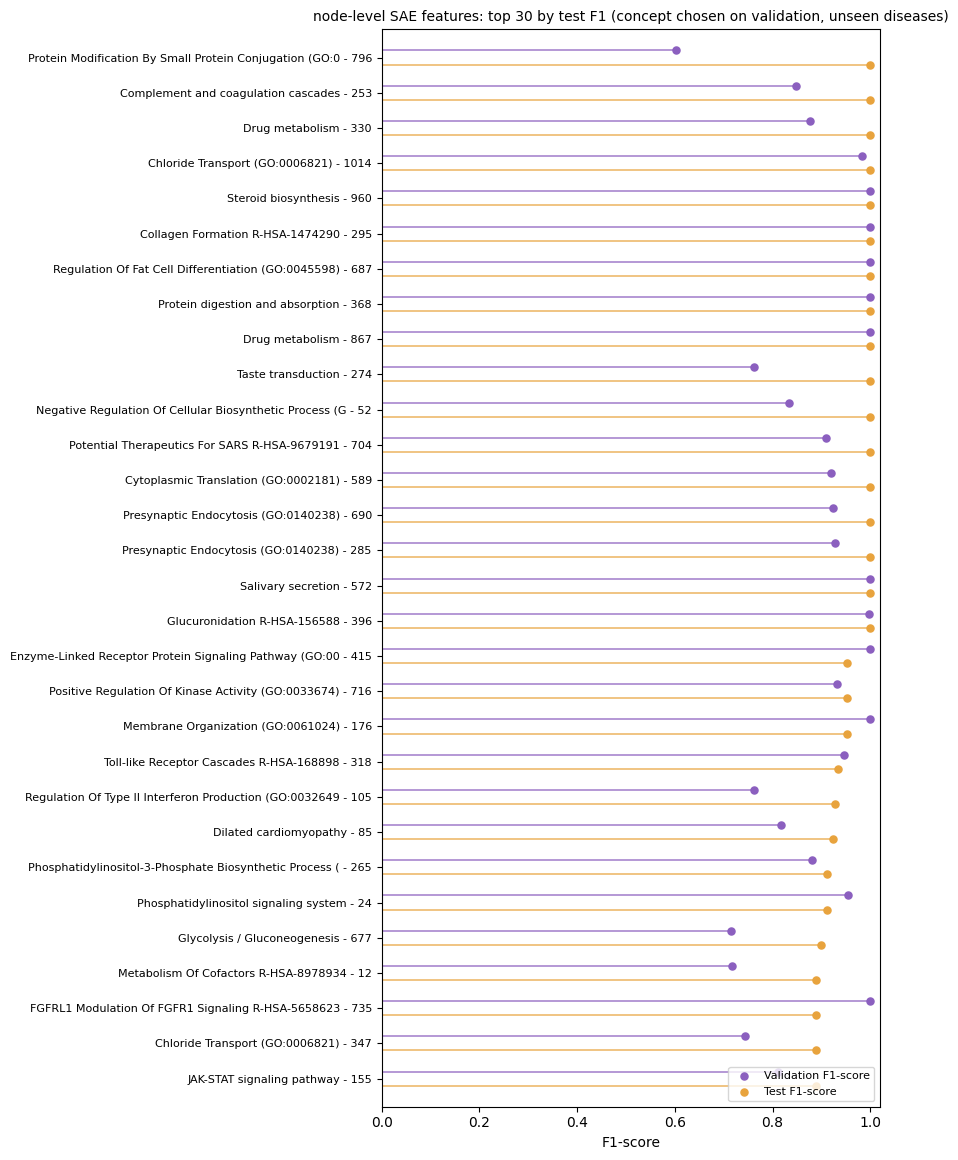

median validation -> test change: +0.051 (0 of 30 features lose more than 0.2)


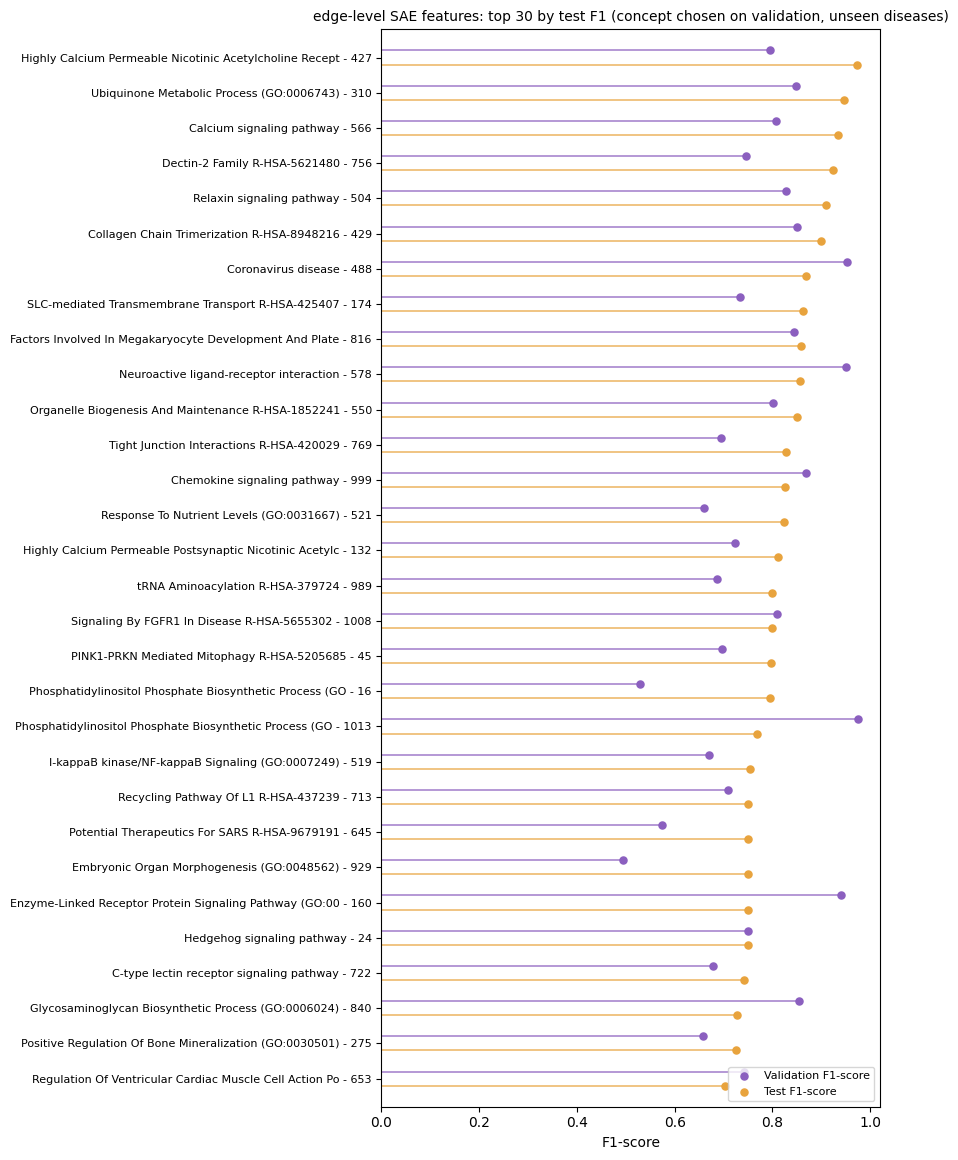

median validation -> test change: +0.075 (1 of 30 features lose more than 0.2)


In [8]:
def plot_val_test_f1(table, level, top_n=30):
    # Ranked by test F1: these are the concepts that actually generalised to held-out diseases,
    # not just the ones that happened to score best on the diseases used to pick them.
    tbl = table.dropna(subset=["f1_test"]).sort_values("f1_test", ascending=False).head(top_n).iloc[::-1]
    labels = [f"{str(t).split(' | ')[-1][:55]} - {int(f)}" for t, f in zip(tbl["term"], tbl["feature"])]
    y = np.arange(len(tbl), dtype=float)
    val, test = tbl["f1_val"].to_numpy(), tbl["f1_test"].to_numpy()
    scored = ~np.isnan(test)
    offset = 0.2

    fig, ax = plt.subplots(figsize=(9, 0.34 * len(tbl) + 1.5))
    ax.hlines(y + offset, 0, val, color="#8b5fbf", lw=1.2, alpha=0.75, zorder=1)
    ax.hlines(y[scored] - offset, 0, test[scored], color="#e8a33d", lw=1.2, alpha=0.75, zorder=1)
    ax.scatter(val, y + offset, s=26, color="#8b5fbf", zorder=3, label="Validation F1-score")
    ax.scatter(test[scored], y[scored] - offset, s=26, color="#e8a33d", zorder=3, label="Test F1-score")

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_ylim(-0.8, len(tbl) - 0.2)
    ax.set_xlabel("F1-score")
    ax.set_xlim(0, 1.02)
    ax.legend(loc="lower right", fontsize=8, frameon=True)
    ax.grid(False)
    ax.set_title(f"{level}-level SAE features: top {top_n} by test F1 "
                 f"(concept chosen on validation, unseen diseases)", fontsize=10)
    plt.tight_layout(); plt.show()

    delta = (tbl["f1_test"] - tbl["f1_val"]).dropna()
    print(f"median validation -> test change: {delta.median():+.3f} "
          f"({(delta < -0.2).sum()} of {len(delta)} features lose more than 0.2)")


plot_val_test_f1(node_table, "node")
plot_val_test_f1(edge_table, "edge")